In [4]:
import sys
from pathlib import Path

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

from src.models.classical import get_regression_models, get_classification_models
from src.models.train import train_classical_model
from src.models.evaluate import regression_metrics, classification_metrics, nasa_scoring_function, compare_models
from src.config import DATASETS, PROCESSED_DIR, MODELS_DIR, RANDOM_STATE
from src.visualization import plot_predicted_vs_actual

sns.set_theme(style="whitegrid")

In [5]:
with open(PROCESSED_DIR / "metadata.json") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]

processed = {}
for ds_id in DATASETS:
    train = pd.read_parquet(PROCESSED_DIR / f"train_{ds_id}.parquet")
    test = pd.read_parquet(PROCESSED_DIR / f"test_{ds_id}.parquet")
    processed[ds_id] = {"train": train, "test": test}
    print(f"{ds_id} — Train: {train.shape} | Test: {test.shape}")

FD001 — Train: (20631, 62) | Test: (100, 20)
FD002 — Train: (53759, 62) | Test: (259, 20)
FD003 — Train: (24720, 62) | Test: (100, 20)
FD004 — Train: (61249, 62) | Test: (248, 20)


In [6]:
ds_id = "FD001"
train = processed[ds_id]["train"]
test = processed[ds_id]["test"]

all_cols = feature_cols[ds_id]
available_cols = [c for c in all_cols if c in test.columns]
print(f"Features en train: {len(all_cols)}")
print(f"Features disponibles en test: {len(available_cols)}")
print(f"Features faltantes en test: {set(all_cols) - set(available_cols)}")

cols = available_cols

X_train = train[cols].values
y_train_reg = train["rul"].values
y_train_clf = train["label"].values

X_test = test[cols].values
y_test_reg = test["rul"].values
y_test_clf = test["label"].values

print(f"\nX_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train RUL range: [{y_train_reg.min()}, {y_train_reg.max()}]")
print(f"y_train label balance: {np.bincount(y_train_clf)}")

Features en train: 58
Features disponibles en test: 16
Features faltantes en test: {'sensor_4_trend', 'sensor_15_roll_std', 'sensor_2_roll_std', 'sensor_11_roll_std', 'sensor_3_roll_std', 'sensor_13_roll_std', 'sensor_14_roll_std', 'sensor_15_roll_mean', 'sensor_14_roll_mean', 'sensor_7_trend', 'sensor_7_roll_std', 'sensor_3_trend', 'sensor_17_roll_std', 'sensor_20_roll_mean', 'sensor_3_roll_mean', 'sensor_12_trend', 'sensor_11_roll_mean', 'sensor_11_trend', 'sensor_14_trend', 'sensor_13_trend', 'sensor_2_roll_mean', 'sensor_8_roll_mean', 'sensor_12_roll_mean', 'sensor_12_roll_std', 'sensor_9_roll_mean', 'sensor_17_trend', 'sensor_13_roll_mean', 'sensor_4_roll_std', 'sensor_8_trend', 'sensor_20_trend', 'sensor_21_roll_std', 'sensor_9_roll_std', 'sensor_7_roll_mean', 'sensor_20_roll_std', 'sensor_4_roll_mean', 'sensor_15_trend', 'sensor_9_trend', 'sensor_8_roll_std', 'sensor_2_trend', 'sensor_21_roll_mean', 'sensor_21_trend', 'sensor_17_roll_mean'}

X_train: (20631, 16)
X_test: (100, 16

In [7]:
reg_models = get_regression_models()
reg_results = {}

for name, model in reg_models.items():
    print(f"\nEntrenando {name}...")
    train_classical_model(model, X_train, y_train_reg, name, ds_id)

    y_pred = model.predict(X_test)
    metrics = regression_metrics(y_test_reg, y_pred)
    reg_results[name] = metrics

    print(f"  RMSE: {metrics['rmse']:.2f} | MAE: {metrics['mae']:.2f} | R²: {metrics['r2']:.4f} | NASA: {metrics['nasa_score']:.2f}")


Entrenando linear_regression...
✓ linear_regression guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\models\linear_regression_FD001.pkl
  RMSE: 21.91 | MAE: 17.61 | R²: 0.7220 | NASA: 1318.89

Entrenando svr...
✓ svr guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\models\svr_FD001.pkl
  RMSE: 19.61 | MAE: 13.82 | R²: 0.7773 | NASA: 1624.85

Entrenando random_forest_reg...
✓ random_forest_reg guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\models\random_forest_reg_FD001.pkl
  RMSE: 17.92 | MAE: 12.92 | R²: 0.8141 | NASA: 886.38

Entrenando xgboost_reg...
✓ xgboost_reg guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\models\xgboost_reg_FD001.pkl
  RMSE: 18.31 | MAE: 13.39 | R²: 0.8060 | NASA: 1058.09


In [8]:
reg_df = compare_models(reg_results)
reg_df.style.background_gradient(cmap="RdYlGn_r", subset=["rmse", "mae", "nasa_score"]).background_gradient(cmap="RdYlGn", subset=["r2"])

,rmse,mae,r2,nasa_score
linear_regression,21.910800,17.608000,0.722000,1318.887500
svr,19.609600,13.817600,0.777300,1624.850500
random_forest_reg,17.918000,12.924100,0.814100,886.378500
xgboost_reg,18.305500,13.386500,0.806000,1058.091900


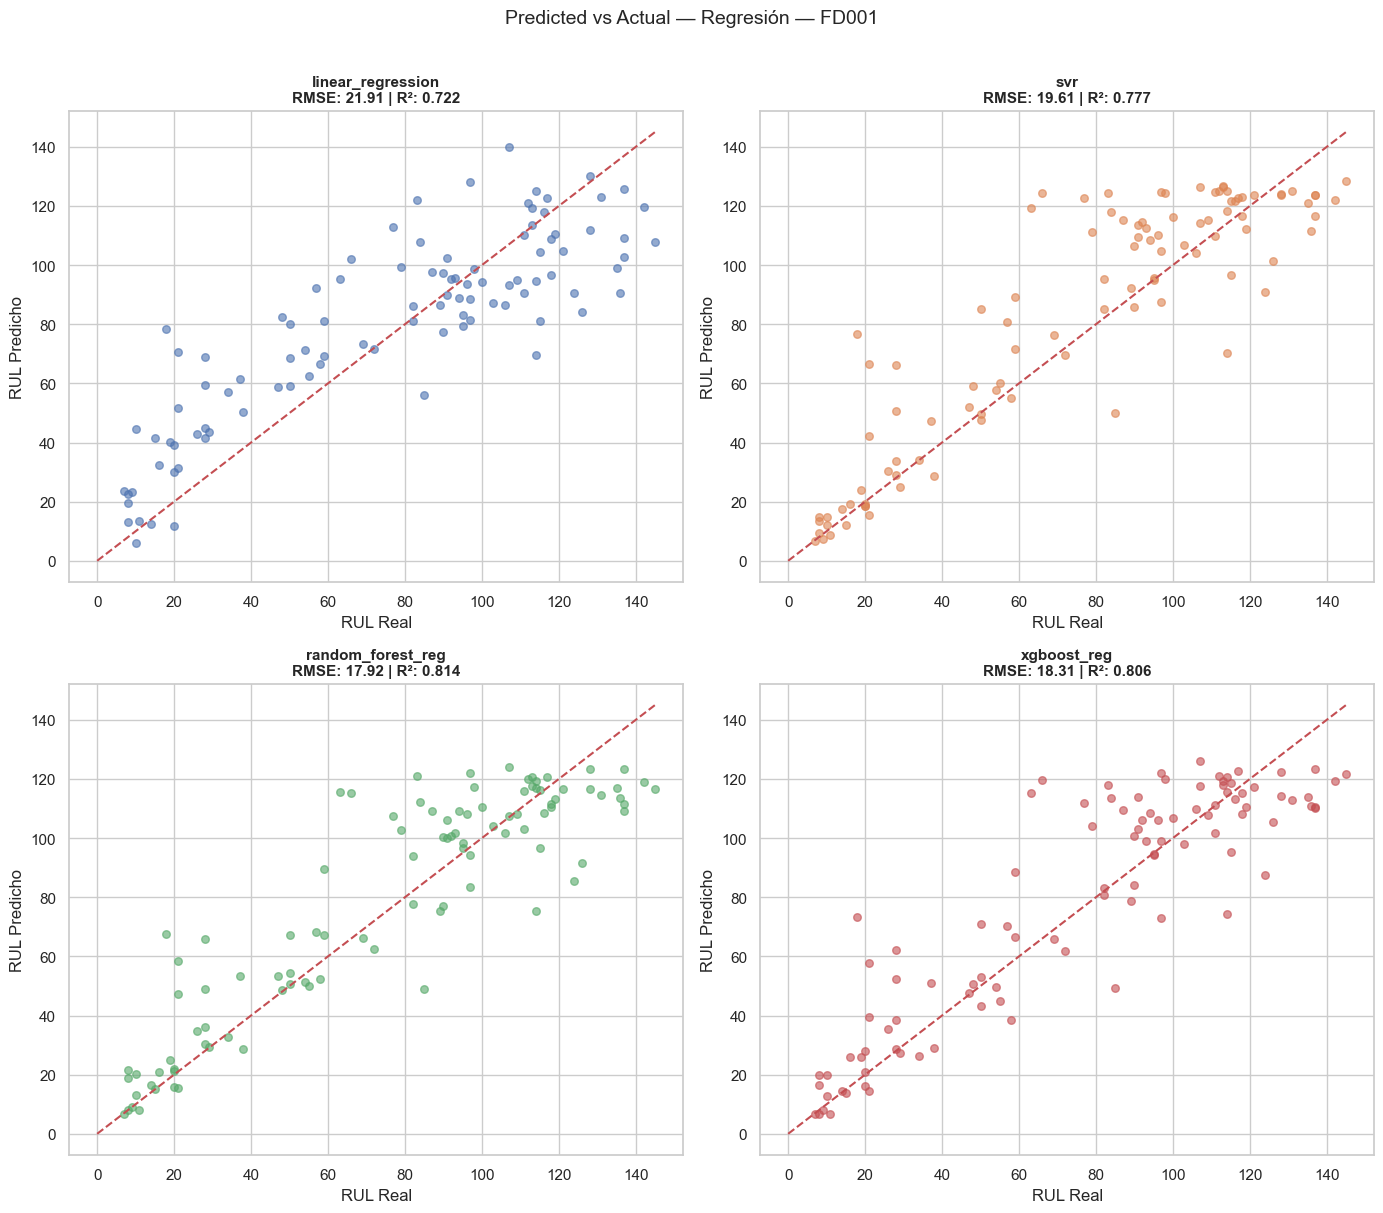

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (name, model) in enumerate(reg_models.items()):
    y_pred = model.predict(X_test)
    axes[i].scatter(y_test_reg, y_pred, alpha=0.6, s=30, color=colors[i])
    axes[i].plot([0, max(y_test_reg)], [0, max(y_test_reg)], "r--", linewidth=1.5)
    axes[i].set_xlabel("RUL Real")
    axes[i].set_ylabel("RUL Predicho")
    axes[i].set_title(f"{name}\nRMSE: {reg_results[name]['rmse']:.2f} | R²: {reg_results[name]['r2']:.3f}", fontsize=11, fontweight="bold")

plt.suptitle(f"Predicted vs Actual — Regresión — {ds_id}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

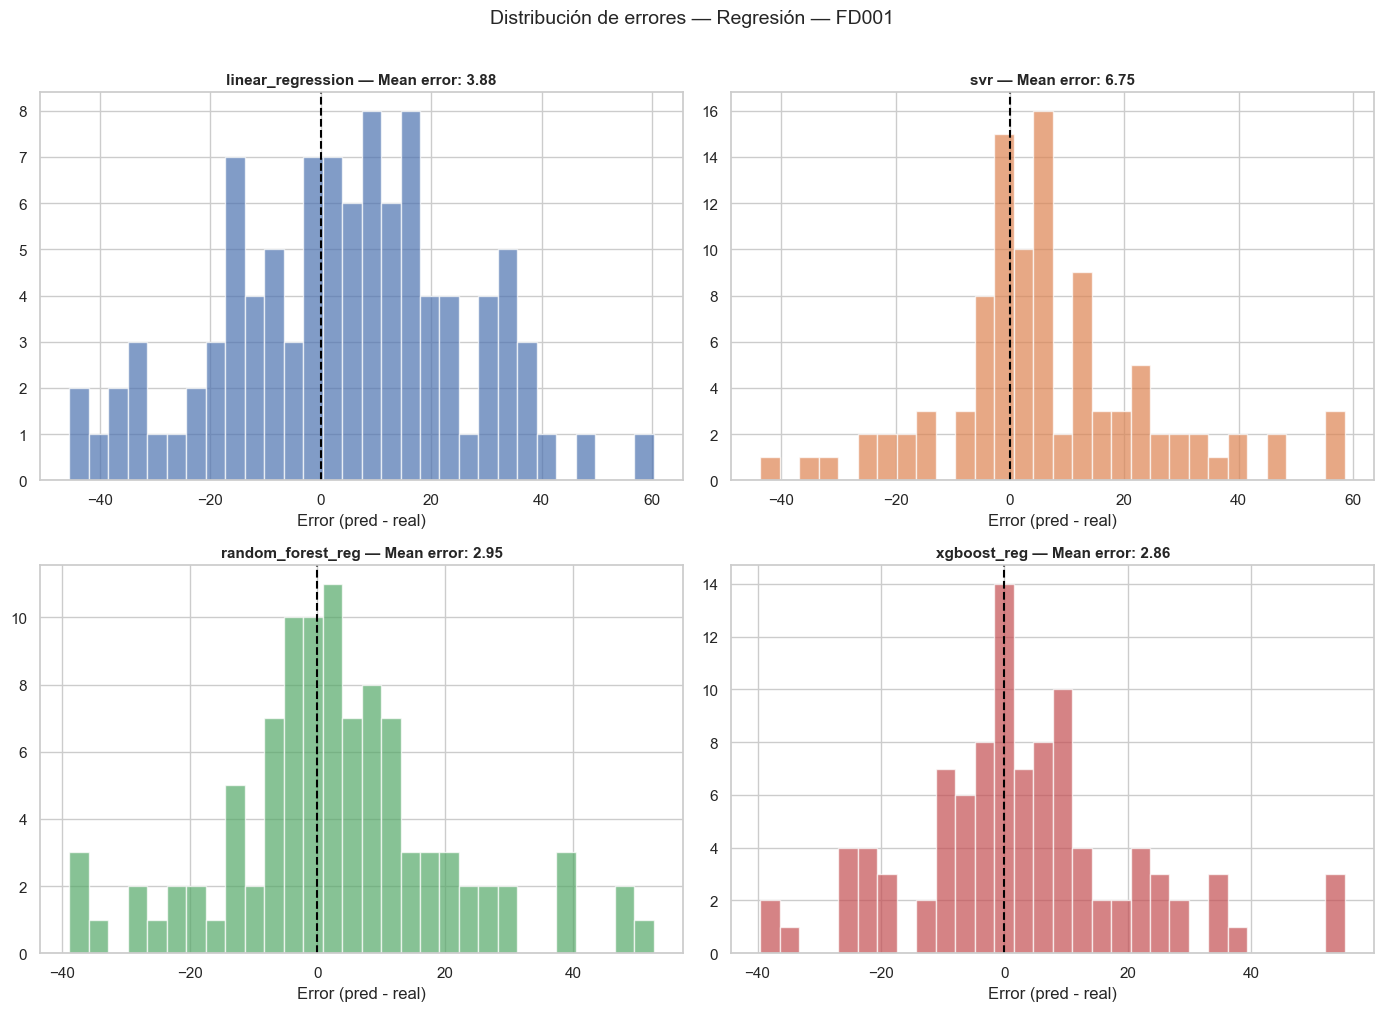

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(reg_models.items()):
    y_pred = model.predict(X_test)
    errors = y_pred - y_test_reg
    axes[i].hist(errors, bins=30, color=colors[i], alpha=0.7, edgecolor="white")
    axes[i].axvline(0, color="black", linestyle="--")
    axes[i].set_title(f"{name} — Mean error: {errors.mean():.2f}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Error (pred - real)")

plt.suptitle(f"Distribución de errores — Regresión — {ds_id}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
clf_models = get_classification_models()
clf_results = {}

for name, model in clf_models.items():
    print(f"\nEntrenando {name}...")
    train_classical_model(model, X_train, y_train_clf, name, ds_id)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = classification_metrics(y_test_clf, y_pred, y_proba)
    clf_results[name] = metrics

    print(f"  Acc: {metrics['accuracy']:.4f} | Prec: {metrics['precision']:.4f} | Rec: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f} | AUC: {metrics['auc_roc']:.4f}")


Entrenando random_forest_clf...
✓ random_forest_clf guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\models\random_forest_clf_FD001.pkl
  Acc: 0.9100 | Prec: 0.9000 | Rec: 0.7200 | F1: 0.8000 | AUC: 0.9829

Entrenando xgboost_clf...
✓ xgboost_clf guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\models\xgboost_clf_FD001.pkl
  Acc: 0.9100 | Prec: 0.9000 | Rec: 0.7200 | F1: 0.8000 | AUC: 0.9797


In [12]:
clf_df = compare_models(clf_results)
clf_df.style.background_gradient(cmap="RdYlGn", subset=["accuracy", "precision", "recall", "f1", "auc_roc"])

,accuracy,precision,recall,f1,auc_roc
random_forest_clf,0.910000,0.900000,0.720000,0.800000,0.982900
xgboost_clf,0.910000,0.900000,0.720000,0.800000,0.979700


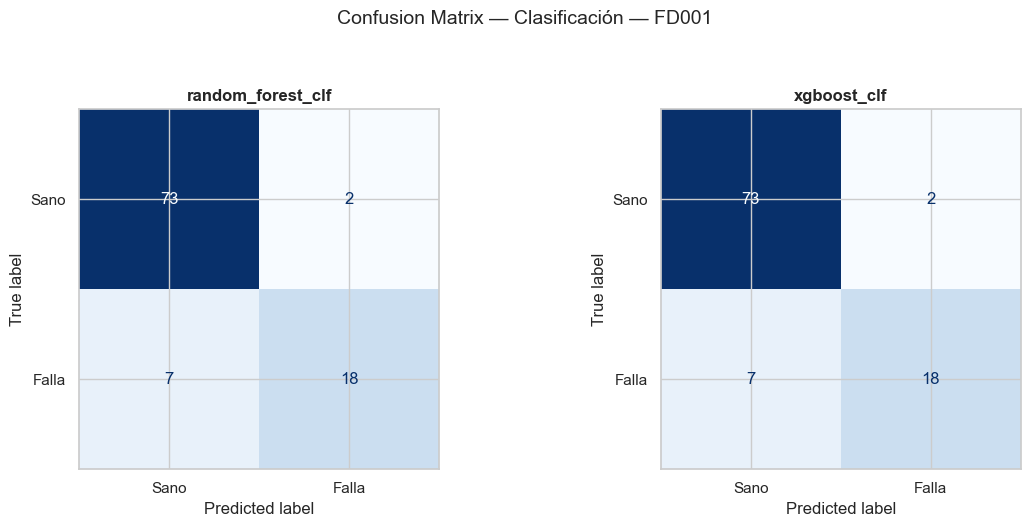

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(clf_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_clf, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Sano", "Falla"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{name}", fontsize=12, fontweight="bold")

plt.suptitle(f"Confusion Matrix — Clasificación — {ds_id}", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

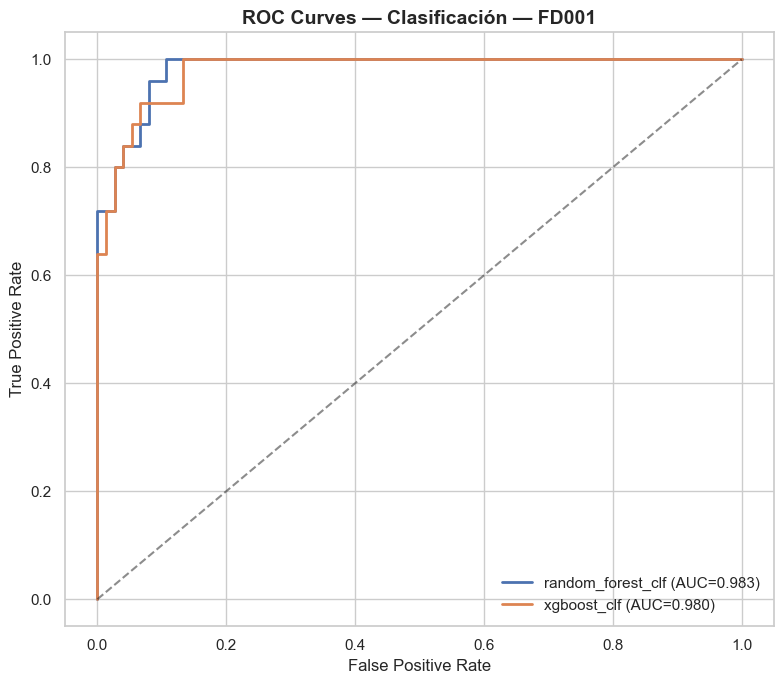

In [14]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 7))

for name, model in clf_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — Clasificación — {ds_id}", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
cv_results = {}

for name, model in get_regression_models().items():
    scores = cross_val_score(model, X_train, y_train_reg, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_results[name] = {"cv_rmse_mean": -scores.mean(), "cv_rmse_std": scores.std()}
    print(f"{name}: CV RMSE = {-scores.mean():.2f} ± {scores.std():.2f}")

cv_df = pd.DataFrame(cv_results).T
cv_df.style.format("{:.2f}").background_gradient(cmap="RdYlGn_r")

linear_regression: CV RMSE = 21.62 ± 0.90
svr: CV RMSE = 18.90 ± 1.42
random_forest_reg: CV RMSE = 18.59 ± 1.48
xgboost_reg: CV RMSE = 18.54 ± 1.48


,cv_rmse_mean,cv_rmse_std
linear_regression,21.62,0.90
svr,18.90,1.42
random_forest_reg,18.59,1.48
xgboost_reg,18.54,1.48


In [17]:
all_reg_results = {}

for ds_id in DATASETS:
    train = processed[ds_id]["train"]
    test = processed[ds_id]["test"]
    all_cols = feature_cols[ds_id]
    available = [c for c in all_cols if c in test.columns]

    X_tr = train[available].values
    y_tr = train["rul"].values
    X_te = test[available].values
    y_te = test["rul"].values

    models = get_regression_models()
    ds_results = {}

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        ds_results[name] = regression_metrics(y_te, y_pred)

    all_reg_results[ds_id] = ds_results
    best = min(ds_results.items(), key=lambda x: x[1]["rmse"])
    print(f"{ds_id}: Mejor = {best[0]} | RMSE = {best[1]['rmse']:.2f}")

FD001: Mejor = random_forest_reg | RMSE = 17.92
FD002: Mejor = xgboost_reg | RMSE = 28.92
FD003: Mejor = random_forest_reg | RMSE = 21.24
FD004: Mejor = xgboost_reg | RMSE = 30.83


In [18]:
rows = []
for ds_id in DATASETS:
    for model_name, metrics in all_reg_results[ds_id].items():
        rows.append({"dataset": ds_id, "model": model_name, **metrics})

cross_df = pd.DataFrame(rows)
pivot_rmse = cross_df.pivot(index="model", columns="dataset", values="rmse")
pivot_rmse.style.format("{:.2f}").background_gradient(cmap="RdYlGn_r", axis=None)

dataset,FD001,FD002,FD003,FD004
model,,,,
linear_regression,21.91,32.50,22.87,36.62
random_forest_reg,17.92,29.29,21.24,31.09
svr,19.61,51.77,22.23,55.46
xgboost_reg,18.31,28.92,21.44,30.83


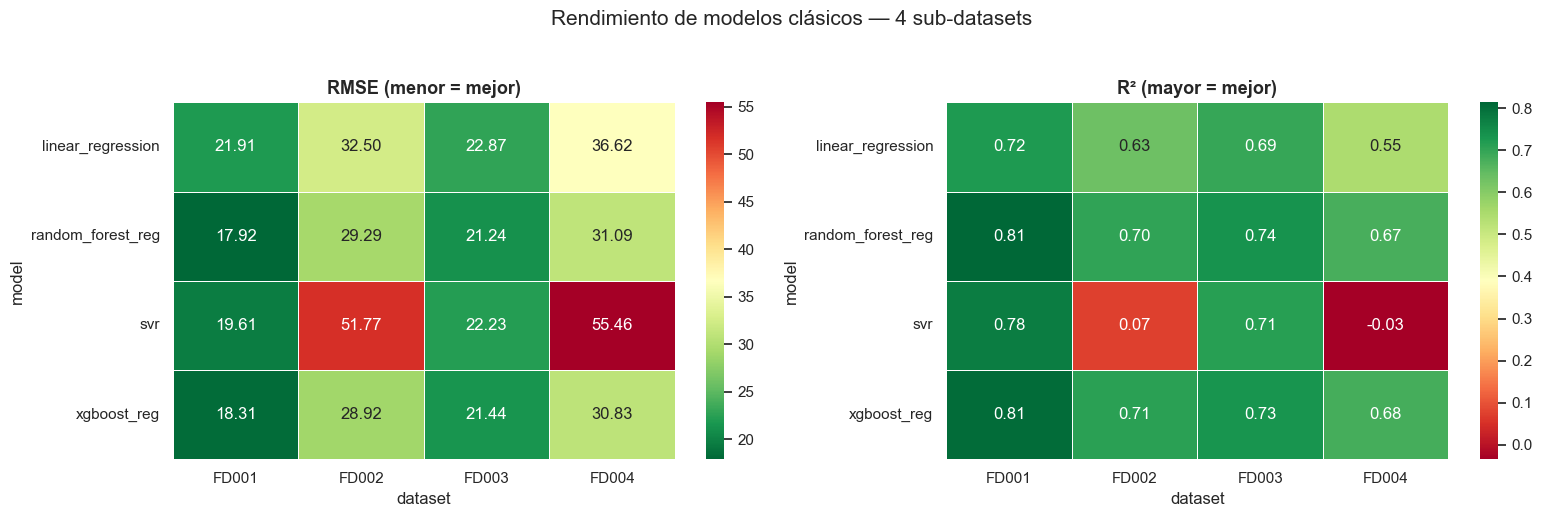

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title, cmap in zip(axes, ["rmse", "r2"], ["RMSE (menor = mejor)", "R² (mayor = mejor)"], ["RdYlGn_r", "RdYlGn"]):
    pivot = cross_df.pivot(index="model", columns="dataset", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.suptitle("Rendimiento de modelos clásicos — 4 sub-datasets", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("  RESUMEN ML CLÁSICO")
print("=" * 60)
for ds_id in DATASETS:
    best = min(all_reg_results[ds_id].items(), key=lambda x: x[1]["rmse"])
    print(f"  {ds_id}: Mejor = {best[0]} | RMSE = {best[1]['rmse']:.2f} | R² = {best[1]['r2']:.3f}")
print(f"\n  Clasificación ({ds_id}):")
for name, m in clf_results.items():
    print(f"    {name}: F1={m['f1']:.3f} | AUC={m['auc_roc']:.3f}")
print("=" * 60)

  RESUMEN ML CLÁSICO
  FD001: Mejor = random_forest_reg | RMSE = 17.92 | R² = 0.814
  FD002: Mejor = xgboost_reg | RMSE = 28.92 | R² = 0.711
  FD003: Mejor = random_forest_reg | RMSE = 21.24 | R² = 0.737
  FD004: Mejor = xgboost_reg | RMSE = 30.83 | R² = 0.680

  Clasificación (FD004):
    random_forest_clf: F1=0.800 | AUC=0.983
    xgboost_clf: F1=0.800 | AUC=0.980


In [3]:
import sys
from pathlib import Path
ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pickle
import pandas as pd
import numpy as np
from src.config import MODELS_DIR, PROCESSED_DIR

train = pd.read_parquet(PROCESSED_DIR / "train_FD001.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_FD001.parquet")

exclude = {"unit_id", "cycle", "rul", "label"}
all_cols = [c for c in train.columns if c not in exclude]
available = [c for c in all_cols if c in test.columns]

print("Columnas:", available[:5], "...")
print("Cantidad:", len(available))

X_test = test[available].values

with open(MODELS_DIR / "xgboost_reg_FD001.pkl", "rb") as f:
    model = pickle.load(f)

preds = model.predict(X_test)
print("Min:", preds.min())
print("Max:", preds.max())
print("Mean:", preds.mean())
print("Criticos (<=30):", (preds <= 30).sum())

Columnas: ['op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4'] ...
Cantidad: 16
Min: 6.57961
Max: 126.16556
Mean: 78.38099
Criticos (<=30): 20
